# 06. Evaluation Expansion

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features) and the lightly tuned models compared in 05_advanced_models.ipynb (`Decision Tree`, `LinearRegression`, `RandomForest`, `XGBoost`, `LightGBM`).

R2 and RMSE tell us how a model does *on average in dollar terms*, but they're dominated by a handful of large-dollar errors on expensive properties (see 04_model_comparison.ipynb / 05_advanced_models.ipynb - RMSE was consistently much worse than MAE for the tree-based models). This notebook adds two percentage-based metrics that are easier to interpret business-wise and less skewed by a few extreme-dollar errors:

- **MAPE** (Mean Absolute Percentage Error): average of `|actual - predicted| / actual`, as a percentage
- **MdAPE** (Median Absolute Percentage Error): same idea, but the *median* instead of the mean - much less sensitive to a handful of badly-mispriced outliers

Here we refit the models using the best hyperparameters selected based on cross-validated MdAPE and conduct a more comprehensive evaluation than in 04_model_comparison.ipynb and 05_advanced_models.ipynb.

It also breaks results down **by price band**, to check directly whether the tree-based models' weakness really is concentrated in the high-price tail, as suspected in earlier notebooks.


In [68]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost "
    ) from e

try:
    from lightgbm import LGBMRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs lightgbm. Install with: pip install lightgbm"
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [69]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(138859, 120)


split
train    126835
test      12024
Name: count, dtype: int64

## 2. Separate features / target using the `split` column

Same pattern as the previous notebooks: `split == "train"` for training, `split == "test"` for the held-out final evaluation.

Feature column names are sanitized before use: several are one-hot columns from the multi-label `Flooring` encoding (02_preprocessing.ipynb section 5), e.g. `cat__Flooring_Bamboo,Carpet,Laminate`, and LightGBM's parser rejects feature names containing certain JSON special characters (`, : [ ] { } "`) - XGBoost and the other models tolerate them, but they're replaced with `_` here so every model in this notebook stays on identical column names.


In [70]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

def sanitize_feature_name(name):
    # LightGBM rejects these JSON special characters in feature names; the other models tolerate
    # them, but all models here are kept on identical (sanitized) column names to avoid any mismatch.
    return re.sub(r'[",:\[\]{}]', "_", name)

raw_feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]
sanitized_names = [sanitize_feature_name(c) for c in raw_feature_cols]

if len(set(sanitized_names)) != len(sanitized_names):
    # Extremely unlikely with this data, but guard against two different raw names colliding
    # onto the same sanitized name (e.g. "A,B" and "A:B" both becoming "A_B").
    seen = {}
    deduped = []
    for name in sanitized_names:
        seen[name] = seen.get(name, 0) + 1
        deduped.append(name if seen[name] == 1 else f"{name}_{seen[name]}")
    sanitized_names = deduped

cleaned_df = cleaned_df.rename(columns=dict(zip(raw_feature_cols, sanitized_names)))
feature_cols = sanitized_names

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# Log-transform the target. ClosePrice is strictly > 0 (filtered in 02_preprocessing),
# so log1p is safe; models are trained on this and predictions are back-transformed
# with expm1 right after predict() (see section 3 below), so every downstream metric
# (R2/MAE/RMSE/MAPE/MdAPE, price-band breakdown) stays in the original $ scale untouched.
y_train_log = np.log1p(y_train)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (126835, 116) | X_test: (12024, 116)


## 3. Walk-forward CV folds within the training window (for tuning only)

Instead of holding out only the last month as a single validation split, several rolling-origin folds are built: each fold holds out one month and trains on every month before it. Hyperparameter combinations in section 4 are scored by their *average* metric across these folds, which is far less sensitive to any single month's quirks than a one-month validation split. The true test month (section 2) is never used until the single final evaluation in section 6.

In [71]:
# --- Walk-forward (rolling-origin) CV folds within the training window ---
# A single last-month validation split can be noisy (one month is a small, possibly unusual
# sample). Instead, build several folds: each fold holds out one month as validation and trains
# on every month strictly before it within train_df. Hyperparameters are then chosen by the
# *average* validation score across folds, not by a single month's luck.
months_in_train = sorted(train_df["year_month"].unique())

N_CV_FOLDS = min(3, len(months_in_train) - 1)  # every fold needs >=1 month left over to train on
if N_CV_FOLDS < 1:
    raise ValueError(f"Not enough months in train_df ({len(months_in_train)}) to build even one CV fold.")

cv_folds = []
for i in range(N_CV_FOLDS):
    val_month = months_in_train[-(i + 1)]
    fold_train_months = months_in_train[: months_in_train.index(val_month)]

    fold_train_df = train_df[train_df["year_month"].isin(fold_train_months)]
    fold_val_df = train_df[train_df["year_month"] == val_month]

    cv_folds.append({
        "val_month": val_month,
        "train_months": fold_train_months,
        "X_train": fold_train_df[feature_cols],
        "y_train": fold_train_df[target],
        "y_train_log": np.log1p(fold_train_df[target]),
        "X_val": fold_val_df[feature_cols],
        "y_val": fold_val_df[target],
    })

for fold in cv_folds:
    print(f"Fold val_month={fold['val_month']} | train_months={fold['train_months']} "
          f"| X_train={fold['X_train'].shape} | X_val={fold['X_val'].shape}")

Fold val_month=2026-04 | train_months=['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03'] | X_train=(115106, 116) | X_val=(11729, 116)
Fold val_month=2026-03 | train_months=['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02'] | X_train=(104206, 116) | X_val=(10900, 116)
Fold val_month=2026-02 | train_months=['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01'] | X_train=(95871, 116) | X_val=(8335, 116)


## 4. hyperparameter search (averaged across CV folds)

A small grid over `max_depth`, `learning_rate`, `n_estimators` for both models (3 × 2 × 2 = 12 combinations each). **LightGBM also gets `num_leaves` in its grid**: LightGBM grows trees *leaf-wise* rather than XGBoost's default *depth-wise* growth, and its actual tree complexity is controlled mainly by `num_leaves` (default 31) - `max_depth` alone is more of a safety cap. Tuning `max_depth` without also tuning `num_leaves` means LightGBM's real complexity barely changes between settings, which isn't a fair comparison against XGBoost. `num_leaves` candidates are kept under `2^max_depth` for each depth, matching LightGBM's own tuning guidance.

Each combination is fit and scored independently on every fold from section 3, then averaged (`val_RMSE_std` is also kept alongside the mean, to see how much the score varies fold-to-fold) - not just fit on a single `tune_train`/scored on a single `tune_val` (`verbose=-1` just silences LightGBM's per-iteration logging - it doesn't affect the fit).

In [73]:
import itertools
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# ---------------------------------------------------------------------------
# Candidate values
# ---------------------------------------------------------------------------
MAX_DEPTH_CANDIDATES = [3, 5, 7]
LEARNING_RATE_CANDIDATES = [0.05, 0.1]
N_ESTIMATORS_CANDIDATES = [200, 400]

TREE_MAX_DEPTH_CANDIDATES = MAX_DEPTH_CANDIDATES + [None]
MIN_SAMPLES_LEAF_CANDIDATES = [1, 5, 10]
RF_MAX_FEATURES_CANDIDATES = ["sqrt", 0.5, 1.0]
XGB_MIN_CHILD_WEIGHT_CANDIDATES = [1, 5, 10]
XGB_SUBSAMPLE_CANDIDATES = [0.8, 1.0]
LGBM_NUM_LEAVES_BY_DEPTH = {3: [7], 5: [15, 31], 7: [31, 63]}
LGBM_MIN_CHILD_SAMPLES_CANDIDATES = [10, 20, 50]


# ---------------------------------------------------------------------------
# Model constructors
# ---------------------------------------------------------------------------
MODEL_CONSTRUCTORS = {
    "XGBoost": lambda **params: XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": lambda **params: LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "DecisionTree": lambda **params: DecisionTreeRegressor(**params, random_state=RANDOM_STATE),
    "RandomForest": lambda **params: RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
    "LinearRegression": lambda **params: LinearRegression(**params),
}


# ---------------------------------------------------------------------------
# Parameter combination generators
# ---------------------------------------------------------------------------
def xgb_param_combinations():
    for max_depth, learning_rate, n_estimators, min_child_weight, subsample in itertools.product(
        MAX_DEPTH_CANDIDATES, LEARNING_RATE_CANDIDATES, N_ESTIMATORS_CANDIDATES,
        XGB_MIN_CHILD_WEIGHT_CANDIDATES, XGB_SUBSAMPLE_CANDIDATES,
    ):
        yield {
            "max_depth": max_depth, "learning_rate": learning_rate, "n_estimators": n_estimators,
            "min_child_weight": min_child_weight, "subsample": subsample,
        }


def lgbm_param_combinations():
    for max_depth in MAX_DEPTH_CANDIDATES:
        for num_leaves in LGBM_NUM_LEAVES_BY_DEPTH[max_depth]:
            for learning_rate, n_estimators, min_child_samples in itertools.product(
                LEARNING_RATE_CANDIDATES, N_ESTIMATORS_CANDIDATES, LGBM_MIN_CHILD_SAMPLES_CANDIDATES
            ):
                yield {
                    "max_depth": max_depth, "num_leaves": num_leaves, "learning_rate": learning_rate,
                    "n_estimators": n_estimators, "min_child_samples": min_child_samples,
                }


def decision_tree_param_combinations():
    for max_depth, min_samples_leaf in itertools.product(TREE_MAX_DEPTH_CANDIDATES, MIN_SAMPLES_LEAF_CANDIDATES):
        yield {"max_depth": max_depth, "min_samples_leaf": min_samples_leaf}


def random_forest_param_combinations():
    for max_depth, n_estimators, min_samples_leaf, max_features in itertools.product(
        TREE_MAX_DEPTH_CANDIDATES, N_ESTIMATORS_CANDIDATES, MIN_SAMPLES_LEAF_CANDIDATES, RF_MAX_FEATURES_CANDIDATES
    ):
        yield {
            "max_depth": max_depth, "n_estimators": n_estimators,
            "min_samples_leaf": min_samples_leaf, "max_features": max_features,
        }


def linear_regression_param_combinations():
    # No hyperparameters to tune - yields a single empty combo so it runs through the
    # same CV loop as the other models, purely as a baseline comparison point.
    yield {}


PARAM_GENERATORS = {
    "XGBoost": xgb_param_combinations,
    "LightGBM": lgbm_param_combinations,
    "DecisionTree": decision_tree_param_combinations,
    "RandomForest": random_forest_param_combinations,
    "LinearRegression": linear_regression_param_combinations,
}


def median_absolute_percentage_error(y_true, y_pred):
    # sklearn has no built-in MdAPE - using the median (instead of MAPE's mean) makes it far
    # less sensitive to the handful-of-extreme-listings problem seen with RMSE earlier.
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.median(np.abs((y_true - y_pred) / y_true))


tuning_results = []

for model_name, constructor in MODEL_CONSTRUCTORS.items():
    for params in PARAM_GENERATORS[model_name]():
        fold_metrics = []
        for fold in cv_folds:
            model = constructor(**params)
            model.fit(fold["X_train"], fold["y_train_log"])
            pred = np.expm1(model.predict(fold["X_val"]))  # back-transform to the original $ scale

            fold_metrics.append({
                "R2": r2_score(fold["y_val"], pred),
                "MAE": mean_absolute_error(fold["y_val"], pred),
                "RMSE": np.sqrt(mean_squared_error(fold["y_val"], pred)),
                # MAPE/MdAPE are reported alongside R2/MAE/RMSE for interpretability (error as
                # a % of price) but are not used to pick the winning hyperparameters here.
                "MAPE": mean_absolute_percentage_error(fold["y_val"], pred),
                "MdAPE": median_absolute_percentage_error(fold["y_val"], pred),
            })

        fold_metrics_df = pd.DataFrame(fold_metrics)
        result_row = {"model": model_name, **params}
        # Average across folds (instead of trusting a single validation month) for a more robust
        # estimate of how well this hyperparameter combination generalizes.
        result_row["val_R2"] = fold_metrics_df["R2"].mean()
        result_row["val_MAE"] = fold_metrics_df["MAE"].mean()
        result_row["val_RMSE"] = fold_metrics_df["RMSE"].mean()
        result_row["val_RMSE_std"] = fold_metrics_df["RMSE"].std()  # fold-to-fold variability, for reference
        result_row["val_MAPE"] = fold_metrics_df["MAPE"].mean()
        result_row["val_MdAPE"] = fold_metrics_df["MdAPE"].mean()
        tuning_results.append(result_row)

        param_str = " | ".join(f"{k}={v}" for k, v in params.items())
        print(f"[{model_name:>12} | {param_str}] val_R2={result_row['val_R2']:.4f} | "
              f"val_RMSE={result_row['val_RMSE']:,.0f} (+/-{result_row['val_RMSE_std']:,.0f}) | "
              f"val_MAPE={result_row['val_MAPE']:.2%} | val_MdAPE={result_row['val_MdAPE']:.2%}")

[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200 | min_child_weight=1 | subsample=0.8] val_R2=0.8498 | val_RMSE=300,387 (+/-2,241) | val_MAPE=14.63% | val_MdAPE=10.85%
[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200 | min_child_weight=1 | subsample=1.0] val_R2=0.8490 | val_RMSE=301,154 (+/-2,414) | val_MAPE=14.62% | val_MdAPE=10.89%
[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200 | min_child_weight=5 | subsample=0.8] val_R2=0.8499 | val_RMSE=300,352 (+/-1,949) | val_MAPE=14.63% | val_MdAPE=10.82%
[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200 | min_child_weight=5 | subsample=1.0] val_R2=0.8491 | val_RMSE=301,143 (+/-2,640) | val_MAPE=14.62% | val_MdAPE=10.87%
[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200 | min_child_weight=10 | subsample=0.8] val_R2=0.8501 | val_RMSE=300,160 (+/-2,091) | val_MAPE=14.63% | val_MdAPE=10.82%
[     XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=

## 5. Validation results

`num_leaves` is `NaN` for every XGBoost row (it doesn't use that hyperparameter) - expected, not a bug.


In [75]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values("val_MdAPE").reset_index(drop=True)
tuning_results_df.to_csv("advanced_model_tuning_results.csv", index=False)
print("Saved advanced_model_tuning_results.csv")

print("Best configuration per model (by validation MdAPE):")
best_per_gbm = tuning_results_df.sort_values("val_MdAPE").groupby("model", as_index=False).first()
display(best_per_gbm)

tuning_results_df


Saved advanced_model_tuning_results.csv
Best configuration per model (by validation MdAPE):


,model,max_depth,learning_rate,n_estimators,min_child_weight,subsample,val_R2,val_MAE,val_RMSE,val_RMSE_std,val_MAPE,val_MdAPE,num_leaves,min_child_samples,min_samples_leaf,max_features
0,DecisionTree,7.0,NaN,NaN,NaN,NaN,0.819612,193704.618480,329317.496153,3855.599738,0.162873,0.118327,NaN,NaN,10.0,None
1,LightGBM,7.0,0.1,400.0,NaN,NaN,0.880255,154231.369298,268253.297217,1086.116931,0.128442,0.092886,63.0,10.0,NaN,None
2,LinearRegression,NaN,NaN,NaN,NaN,NaN,0.675741,219712.829835,440866.440011,51173.629296,0.182973,0.137726,NaN,NaN,NaN,None
3,RandomForest,7.0,NaN,400.0,NaN,NaN,0.868541,159440.930344,281016.202147,3594.807373,0.131873,0.094083,NaN,NaN,1.0,0.5
4,XGBoost,7.0,0.1,400.0,1.0,0.8,0.880334,153572.569507,268134.001211,1291.299695,0.127764,0.092827,NaN,NaN,NaN,None


,model,max_depth,learning_rate,n_estimators,min_child_weight,subsample,val_R2,val_MAE,val_RMSE,val_RMSE_std,val_MAPE,val_MdAPE,num_leaves,min_child_samples,min_samples_leaf,max_features
0,XGBoost,7.0,0.1,400.0,1.0,0.8,0.880334,153572.569507,268134.001211,1291.299695,0.127764,0.092827,NaN,NaN,NaN,NaN
1,LightGBM,7.0,0.1,400.0,NaN,NaN,0.880255,154231.369298,268253.297217,1086.116931,0.128442,0.092886,63.0,10.0,NaN,NaN
2,XGBoost,7.0,0.1,400.0,5.0,0.8,0.880673,153814.488767,267745.566145,1091.791967,0.128014,0.092914,NaN,NaN,NaN,NaN
3,XGBoost,7.0,0.1,400.0,10.0,1.0,0.880695,153716.637763,267774.369087,1723.623340,0.127940,0.092999,NaN,NaN,NaN,NaN
4,XGBoost,7.0,0.1,400.0,10.0,0.8,0.880315,153619.256867,268184.618259,2322.058026,0.128019,0.093088,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,RandomForest,3.0,NaN,200.0,NaN,NaN,0.378398,366559.576103,611570.326872,18755.043488,0.324514,0.245856,NaN,NaN,1.0,sqrt
213,RandomForest,3.0,NaN,200.0,NaN,NaN,0.378397,366559.902675,611570.791895,18755.388850,0.324514,0.245856,NaN,NaN,10.0,sqrt
214,RandomForest,3.0,NaN,400.0,NaN,NaN,0.359275,374313.137153,620919.277731,19966.511759,0.331135,0.253525,NaN,NaN,10.0,sqrt
215,RandomForest,3.0,NaN,400.0,NaN,NaN,0.359275,374313.130342,620919.318241,19966.476057,0.331135,0.253525,NaN,NaN,5.0,sqrt


## 6. Retrain the best configuration of each model on the full training window & evaluate on the true test month

The winning hyperparameters (lowest `val_MdAPE`) *for each of models separately* are refit on the **entire** training window (`X_train`/`y_train`, i.e. `tune_train` + the validation month combined) - the validation split was only a tool for picking hyperparameters, so the final models shouldn't be trained on less data than necessary. Both are evaluated against the true test month exactly once.


In [78]:
MODEL_PARAM_COLUMNS = {
    "XGBoost": ["max_depth", "learning_rate", "n_estimators", "min_child_weight", "subsample"],
    "LightGBM": ["max_depth", "num_leaves", "learning_rate", "n_estimators", "min_child_samples"],
    "DecisionTree": ["max_depth", "min_samples_leaf"],
    "RandomForest": ["max_depth", "n_estimators", "min_samples_leaf", "max_features"],
    "LinearRegression": [],
}

INT_PARAMS = {"max_depth", "num_leaves", "n_estimators", "min_child_weight", "min_child_samples", "min_samples_leaf"}
# max_depth=None ("unconstrained") is a valid, deliberately-included candidate (section 4) - it
# must stay Python None rather than being dropped as if the column were simply not applicable.
NONE_ALLOWED_PARAMS = {"max_depth"}


def extract_params(row, model_name):
    params = {}
    for col in MODEL_PARAM_COLUMNS[model_name]:
        val = row.get(col)
        if pd.isna(val):
            if col in NONE_ALLOWED_PARAMS:
                params[col] = None
            continue
        if col in INT_PARAMS:
            params[col] = int(val)
        elif col == "max_features":
            # max_features is either a fraction (0.5 / 1.0) or the string "sqrt" - only the
            # numeric candidates need casting, "sqrt" is passed through as-is.
            params[col] = val if isinstance(val, str) else float(val)
        else:
            params[col] = float(val)
    return params


model_best_params = {}
model_objects = {}
model_test_metrics = {}

for model_name, constructor in MODEL_CONSTRUCTORS.items():
    model_rows = tuning_results_df[tuning_results_df["model"] == model_name]
    if model_rows.empty:
        continue
    best_row = model_rows.sort_values("val_MdAPE").iloc[0]
    params = extract_params(best_row, model_name)
    model_best_params[model_name] = params
    print(f"Best {model_name} hyperparameters (by validation MdAPE): {params}")

    model = constructor(**params)
    model.fit(X_train, y_train_log)
    pred = np.expm1(model.predict(X_test))  # back-transform to the original $ scale

    model_objects[model_name] = model
    model_test_metrics[model_name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAPE": mean_absolute_percentage_error(y_test, pred),
        "MdAPE": median_absolute_percentage_error(y_test, pred),
    }

    metrics = model_test_metrics[model_name]
    print(f"{model_name} (tuned) - R2: {metrics['R2']:.4f} | MAE: {metrics['MAE']:,.0f} | "
          f"RMSE: {metrics['RMSE']:,.0f} | MAPE: {metrics['MAPE']:.2%} | MdAPE: {metrics['MdAPE']:.2%}\n")

xgb_model, lgbm_model = model_objects["XGBoost"], model_objects["LightGBM"]
xgb_test_metrics, lgbm_test_metrics = model_test_metrics["XGBoost"], model_test_metrics["LightGBM"]

tree_model, forest_model = model_objects["DecisionTree"], model_objects["RandomForest"]
tree_test_metrics, forest_test_metrics = model_test_metrics["DecisionTree"], model_test_metrics["RandomForest"]

linear_model = model_objects["LinearRegression"]
linear_test_metrics = model_test_metrics["LinearRegression"]


overall_rows = []
for model_name, metrics in model_test_metrics.items():
    row = {"model": model_name, "price_band": "Overall", "n_rows": len(y_test)}
    row.update(metrics)  
    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).sort_values("MdAPE").reset_index(drop=True)
overall_df

Best XGBoost hyperparameters (by validation MdAPE): {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'subsample': 0.8}
XGBoost (tuned) - R2: 0.4049 | MAE: 237,625 | RMSE: 1,294,507 | MAPE: 16.92% | MdAPE: 9.22%

Best LightGBM hyperparameters (by validation MdAPE): {'max_depth': 7, 'num_leaves': 63, 'learning_rate': 0.1, 'n_estimators': 400, 'min_child_samples': 10}
LightGBM (tuned) - R2: 0.4040 | MAE: 237,801 | RMSE: 1,295,490 | MAPE: 16.74% | MdAPE: 9.17%

Best DecisionTree hyperparameters (by validation MdAPE): {'max_depth': None, 'min_samples_leaf': 10}
DecisionTree (tuned) - R2: 0.3678 | MAE: 282,699 | RMSE: 1,334,262 | MAPE: 19.95% | MdAPE: 11.61%

Best RandomForest hyperparameters (by validation MdAPE): {'max_depth': None, 'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5}
RandomForest (tuned) - R2: 0.3767 | MAE: 249,359 | RMSE: 1,324,845 | MAPE: 17.19% | MdAPE: 9.28%

Best LinearRegression hyperparameters (by validation MdAPE): {}


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,LightGBM,Overall,12024,0.403991,237800.861129,1.295490e+06,0.167369,0.091678
1,XGBoost,Overall,12024,0.404894,237624.605223,1.294507e+06,0.169207,0.092166
2,RandomForest,Overall,12024,0.376674,249358.815883,1.324845e+06,0.171883,0.092769
3,DecisionTree,Overall,12024,0.367781,282699.405259,1.334262e+06,0.199458,0.116108
4,LinearRegression,Overall,12024,0.315919,306216.459773,1.387910e+06,0.238447,0.135501


In [79]:
for name, model in model_objects.items():
    print(name, model.get_params() if hasattr(model, "get_params") else "N/A")

XGBoost {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 400, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}
LightGBM {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.

## 7. Which price bands perform better?

The test set is split into 5 roughly equal-sized price bands (quintiles of the actual `ClosePrice`, so each band has a similar number of properties). MAPE/MdAPE/RMSE are computed separately within each band for every model, to see whether errors really do concentrate in the high-price tail as suspected in 04_model_comparison.ipynb / 05_advanced_models.ipynb.


In [80]:
def evaluate_full(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "MdAPE": median_absolute_percentage_error(y_true, y_pred),
    }


# Predictions from every model trained in section 6 (not just gradient boosting) - reused
# here instead of refitting, so the price-band breakdown covers all 5 models.
predictions = {
    model_name: np.expm1(model.predict(X_test))
    for model_name, model in model_objects.items()
}

N_PRICE_BANDS = 5

price_bands = pd.qcut(y_test, q=N_PRICE_BANDS)
band_labels = [f"${int(b.left):,} - ${int(b.right):,}" for b in price_bands.cat.categories]
price_band_series = price_bands.cat.rename_categories(band_labels)

band_rows = []
for name, pred in predictions.items():
    for band in band_labels:
        band_mask = (price_band_series == band).values
        if band_mask.sum() == 0:
            continue
        row = {"model": name, "price_band": band, "n_rows": int(band_mask.sum())}
        row.update(evaluate_full(y_test[band_mask], pred[band_mask]))
        band_rows.append(row)

band_df = pd.DataFrame(band_rows)
band_df

,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost,"$11,899 - $580,000",2422,-0.545038,63320.806465,1.302186e+05,0.331792,0.085446
1,XGBoost,"$580,000 - $807,500",2389,-1.496884,70655.391874,1.034145e+05,0.101802,0.071545
2,XGBoost,"$807,500 - $1,125,000",2433,-2.021195,107889.530906,1.582292e+05,0.113631,0.083226
3,XGBoost,"$1,125,000 - $1,690,000",2383,-1.406792,174529.656289,2.450764e+05,0.126592,0.099601
4,XGBoost,"$1,690,000 - $97,972,500",2397,0.130014,774568.264132,2.879774e+06,0.170882,0.132906
5,LightGBM,"$11,899 - $580,000",2422,-0.471357,62971.887903,1.270757e+05,0.323380,0.084414
6,LightGBM,"$580,000 - $807,500",2389,-1.504617,70657.690904,1.035745e+05,0.101713,0.072582
7,LightGBM,"$807,500 - $1,125,000",2433,-1.863281,106773.521228,1.540385e+05,0.112279,0.083592
8,LightGBM,"$1,125,000 - $1,690,000",2383,-1.362962,173945.213781,2.428346e+05,0.126187,0.098735
9,LightGBM,"$1,690,000 - $97,972,500",2397,0.128340,777516.477496,2.882543e+06,0.172026,0.130281


## 8. Visualize price-band performance

MdAPE (robust to outliers) is plotted alongside RMSE (sensitive to outliers) for the same price bands, side by side - the contrast between the two is the clearest way to see whether a model's high-price-band weakness is really about typical accuracy or about a few extreme misses.


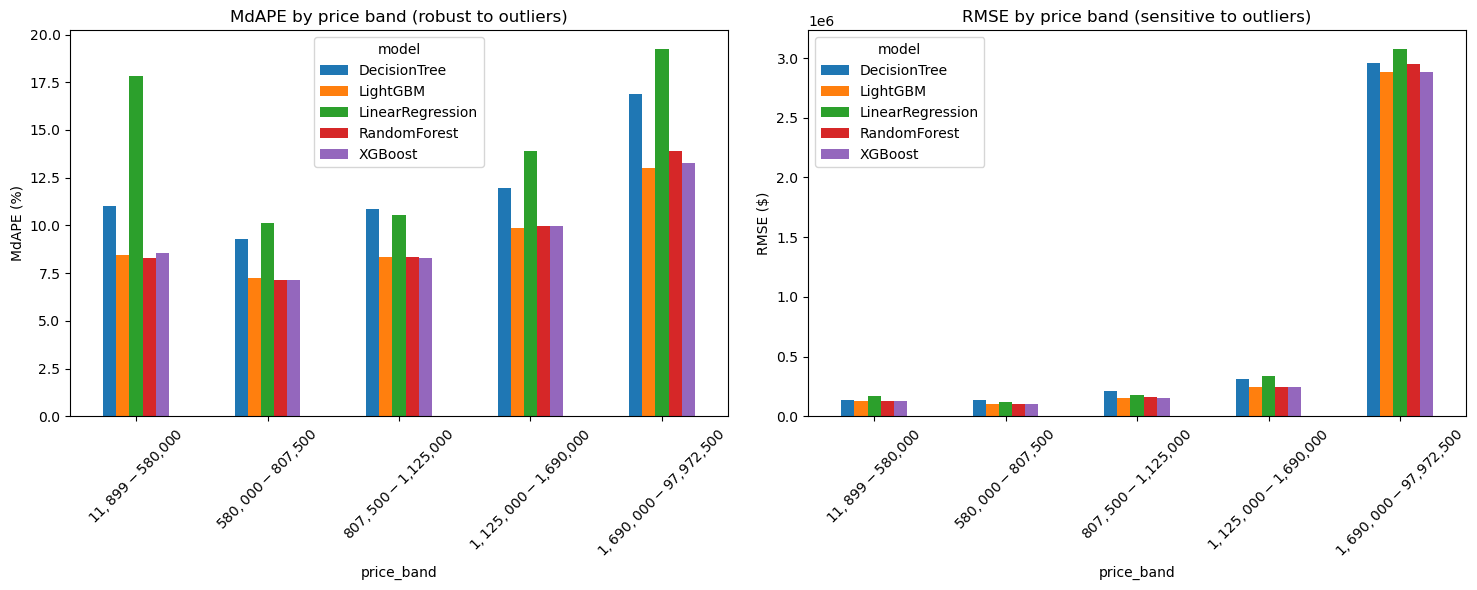

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pivot_mdape = (band_df.pivot(index="price_band", columns="model", values="MdAPE") * 100).loc[band_labels]
pivot_mdape.plot(kind="bar", ax=axes[0])
axes[0].set_title("MdAPE by price band (robust to outliers)")
axes[0].set_ylabel("MdAPE (%)")
axes[0].tick_params(axis="x", rotation=45)

pivot_rmse = band_df.pivot(index="price_band", columns="model", values="RMSE").loc[band_labels]
pivot_rmse.plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE by price band (sensitive to outliers)")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 9. Insights summary & save `metrics_summary.csv`

Combines the overall metrics (section 5) and the per-price-band breakdown (section 6) into one long-format table - `price_band == "Overall"` rows give the whole-test-set numbers, and the rest give the quintile breakdown.


In [82]:
metrics_summary = pd.concat([overall_df, band_df], ignore_index=True)
metrics_summary = metrics_summary[["model", "price_band", "n_rows", "R2", "MAE", "RMSE", "MAPE", "MdAPE"]]

metrics_summary.to_csv("metrics_summary.csv", index=False)
print("Saved metrics_summary.csv")
metrics_summary

Saved metrics_summary.csv


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,LightGBM,Overall,12024,0.403991,237800.861129,1.295490e+06,0.167369,0.091678
1,XGBoost,Overall,12024,0.404894,237624.605223,1.294507e+06,0.169207,0.092166
2,RandomForest,Overall,12024,0.376674,249358.815883,1.324845e+06,0.171883,0.092769
3,DecisionTree,Overall,12024,0.367781,282699.405259,1.334262e+06,0.199458,0.116108
4,LinearRegression,Overall,12024,0.315919,306216.459773,1.387910e+06,0.238447,0.135501
5,XGBoost,"$11,899 - $580,000",2422,-0.545038,63320.806465,1.302186e+05,0.331792,0.085446
6,XGBoost,"$580,000 - $807,500",2389,-1.496884,70655.391874,1.034145e+05,0.101802,0.071545
7,XGBoost,"$807,500 - $1,125,000",2433,-2.021195,107889.530906,1.582292e+05,0.113631,0.083226
8,XGBoost,"$1,125,000 - $1,690,000",2383,-1.406792,174529.656289,2.450764e+05,0.126592,0.099601
9,XGBoost,"$1,690,000 - $97,972,500",2397,0.130014,774568.264132,2.879774e+06,0.170882,0.132906


## Summary

### Overall test-set ranking (by MdAPE)

- **LightGBM and XGBoost are effectively tied** for best (MdAPE within 0.05 pp of each other, R^2 within 0.001) - either is a reasonable production candidate, with LightGBM's much shorter fold-to-fold RMSE std during tuning (section 5) a mild point in its favor for stability.
- **RandomForest closes most of the gap to the boosted models** once `max_features=0.5` is tuned in (unlike the untuned default seen in `05_advanced_models.ipynb`, where it barely outperformed a single Decision Tree) - but still trails LightGBM/XGBoost by ~0.1 pp MdAPE.
- **DecisionTree and LinearRegression remain the weakest** by every metric, exactly as in the earlier notebooks - a single tree still overfits even after tuning `min_samples_leaf`, and linear regression can't capture the non-linear pricing patterns the tree-based models pick up.


### Price-band breakdown (section 7-8)

- **MdAPE by band is mildly U-shaped for the two best models** (XGBoost / LightGBM): ~8.5% in the cheapest quintile, dropping to ~7.2% in the second quintile, then climbing back up to ~13% in the most expensive quintile ($1.69M+). So there is a real, if modest, concentration of *relative* error at the high-price tail - confirming the suspicion from `04_model_comparison.ipynb` / `05_advanced_models.ipynb`, but the effect is much smaller than the RMSE numbers alone would suggest.

### Bottom line

LightGBM and XGBoost are the recommended models from this comparison, with very similar accuracy overall and across price bands. Their main remaining weakness is concentrated in the small number of very high-end listings (top ~20% by price), where dollar errors are large in absolute terms even though relative (percentage) error only degrades modestly - worth keeping in mind if this model is used for pricing decisions on luxury properties specifically.

- Deliverables: `metrics_summary.csv` (overall + per-price-band metrics for all four models), this notebook (`06_evaluation.ipynb`)
